# IFN680 Project 4 - AI Auditing - Case 3 - 'Young' Predictor (High-Confidence Bypass)

**Student 1:** Karan Rooprai  **Student ID:** N12498122
**Student 2:** Nhu Hieu Nguyen  **Student ID:** N12194778

A social-media tagging model predicts whether a person looks young and auto-publishes any prediction with >=99% probability without human review. In deployment it publishes wrong tags while still reporting near-certain confidence. This notebook audits why.

**Auditing approach (exploratory).** We are not retraining the model. We load the delivered
model and its two test sets, then run a standard diagnostic battery using only the techniques from
the Week 5 tutorial - confusion matrices, precision / recall / F1, predicted-probability
distributions, ROC curves, calibration (reliability) diagrams, and CAM saliency maps - comparing
the **internal** set (same distribution as training) against the **external** field set, and let
the evidence indicate the root cause.

## 1. Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import ConfusionMatrixDisplay

# reproducibility + device
torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


## 2. Load the two test sets

`test_internal` is the studio / lab-phase distribution the model was validated on; `test_external`
is the field data where it fails. Each has two folders, `negative` and `positive`
(`positive` = **young**). Images are resized to 224x224 and normalised with the ImageNet
statistics, exactly as in the delivered start notebook.

In [2]:
# Locate CaseXDataset wherever the notebook is run from (cwd, ~/AssessmentX, or a CaseX subfolder)
CASE = 3
DATA_NAME = f'Case{CASE}Dataset'
candidates = [
    DATA_NAME,
    os.path.join(f'Case{CASE}', DATA_NAME),
    os.path.expanduser(f'~/Assessment4/Case{CASE}/{DATA_NAME}'),
    os.path.expanduser(f'~/Assessment4/{DATA_NAME}'),
]
DATA_ROOT = next((p for p in candidates if os.path.isdir(p)), None)
assert DATA_ROOT is not None, f"Could not find {DATA_NAME}. Edit DATA_ROOT to point at it."
print('Dataset root:', DATA_ROOT)

# Remove any hidden checkpoint folders so ImageFolder does not treat them as a class
import shutil
for root, dirs, files in os.walk(DATA_ROOT):
    for d in list(dirs):
        if d == '.ipynb_checkpoints':
            shutil.rmtree(os.path.join(root, d))

Dataset root: Case3/Case3Dataset


In [3]:
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds  = (0.229, 0.224, 0.225)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

internal_ds = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test_internal'), transform=transform)
external_ds = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test_external'), transform=transform)
class_names = internal_ds.classes            # ['negative', 'positive']
print('Classes (index order):', class_names)
print('Internal size:', len(internal_ds), '| External size:', len(external_ds))

batch_size = 32
internal_loader = torch.utils.data.DataLoader(internal_ds, batch_size=batch_size, shuffle=False, num_workers=0)
external_loader = torch.utils.data.DataLoader(external_ds, batch_size=batch_size, shuffle=False, num_workers=0)

Classes (index order): ['negative', 'positive']
Internal size: 300 | External size: 300


### 2.1 Qualitative look: internal vs external samples

Before any metric, we eyeball a few images from each set - image quality, framing and style
differences between the lab and field distributions are often visible by eye.

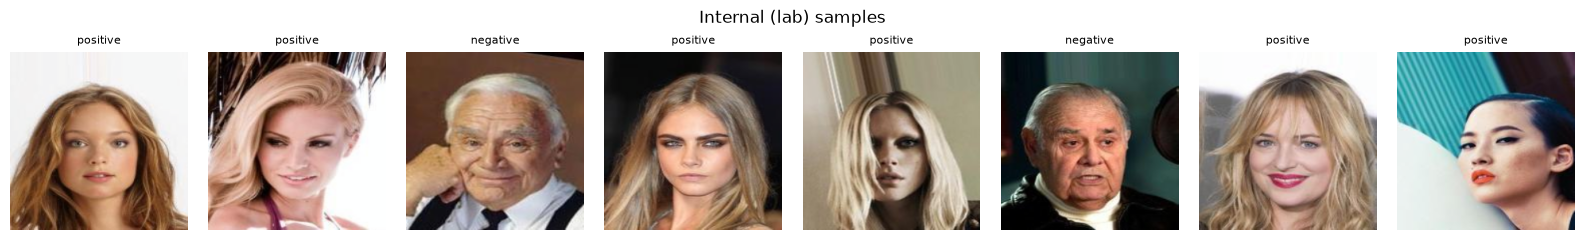

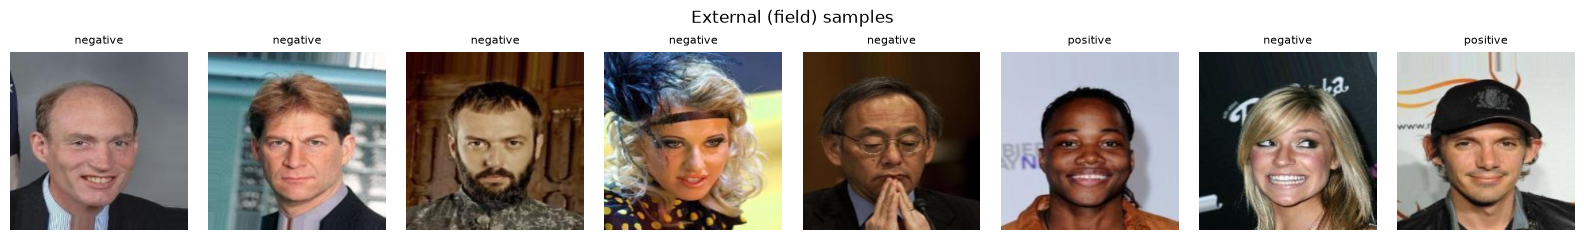

In [4]:
def show_samples(ds, title, n=8):
    idx = np.random.choice(len(ds), size=n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.4))
    for ax, i in zip(axes, idx):
        img, y = ds[i]
        img = img.numpy().transpose(1, 2, 0) * imagenet_stds + imagenet_means
        ax.imshow(np.clip(img, 0, 1)); ax.axis('off'); ax.set_title(class_names[y], fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_samples(internal_ds, 'Internal (lab) samples')
show_samples(external_ds, 'External (field) samples')

## 3. Load the delivered model

A ResNet-18 whose final layer was replaced with a 2-class head and trained by the previous team.
We load the provided weights, put it in eval mode, and move it to the device. No weights are
changed anywhere in this notebook.

In [5]:
def setup_model(model, num_classes, freeze_backbone=False):
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if freeze_backbone:
        for p in model.parameters(): p.requires_grad = False
        for p in model.fc.parameters(): p.requires_grad = True
    return model

# Find the delivered weights next to the dataset
weight_candidates = [
    'resnet_frozen_best.pth',
    os.path.join(f'Case{CASE}', 'resnet_frozen_best.pth'),
    os.path.join(os.path.dirname(DATA_ROOT), 'resnet_frozen_best.pth'),
    os.path.expanduser(f'~/Assessment4/Case{CASE}/resnet_frozen_best.pth'),
]
WEIGHTS = next((p for p in weight_candidates if os.path.isfile(p)), None)
assert WEIGHTS is not None, "Could not find resnet_frozen_best.pth"
print('Weights:', WEIGHTS)

backbone = torchvision.models.resnet18(weights=None)
model = setup_model(backbone, 2)
model.load_state_dict(torch.load(WEIGHTS, map_location=device))
model = model.to(device).eval()

Weights: Case3/resnet_frozen_best.pth


## 4. Collect predictions

For each split we record the ground-truth label and the softmax probability of the positive class.
Everything below is derived from these arrays, so the audit is fully reproducible. We also cache
them to a pickle as required.

In [6]:
import pickle

@torch.no_grad()
def collect(loader):
    labels, prob_pos = [], []
    for inputs, y in loader:
        inputs = inputs.to(device)
        probs = torch.softmax(model(inputs), dim=1)   # [N,2]
        prob_pos.append(probs[:, 1].cpu().numpy())    # P(positive)
        labels.append(y.numpy())
    return np.concatenate(labels), np.concatenate(prob_pos)

results = {}
for split, loader in [('internal', internal_loader), ('external', external_loader)]:
    y, p = collect(loader)
    results[split] = {'labels': y, 'prob_pos': p}
    acc = ((p > 0.5).astype(int) == y).mean()
    print(f"{split:9s}  n={len(y):4d}   accuracy={acc:.3f}")

with open(f'case{CASE}_predictions.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved case%d_predictions.pkl' % CASE)

internal   n= 300   accuracy=0.973
external   n= 300   accuracy=0.593
Saved case3_predictions.pkl


## 5. Confusion matrices and precision / recall / F1

The headline gap is internal vs external accuracy. The confusion matrices and per-threshold
metrics show *how* the errors are distributed (e.g. one-sided false positives/negatives).

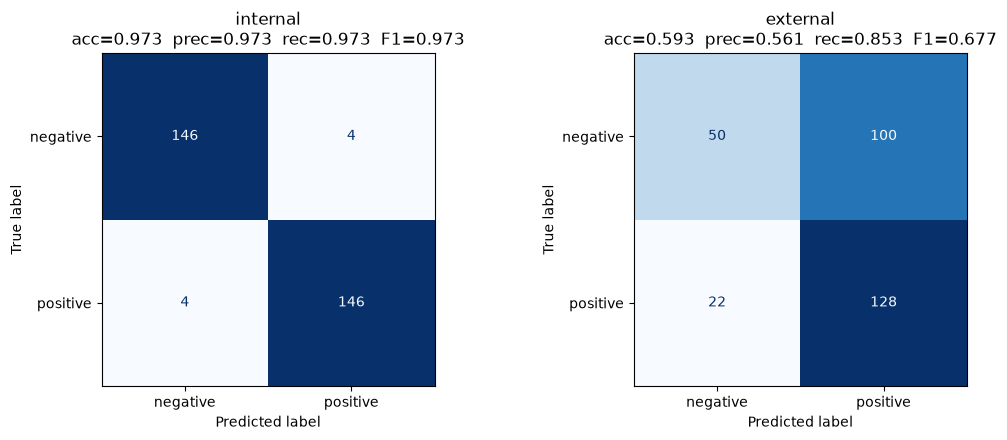

split          acc    prec     rec      F1
internal     0.973   0.973   0.973   0.973
external     0.593   0.561   0.853   0.677


In [7]:
def confusion_counts(labels, probs, threshold=0.5):
    labels = labels.astype(bool); preds = probs > threshold
    tp = np.logical_and(preds, labels).sum()
    fp = np.logical_and(preds, ~labels).sum()
    tn = np.logical_and(~preds, ~labels).sum()
    fn = np.logical_and(~preds, labels).sum()
    return tp, fp, tn, fn

def metrics(labels, probs, threshold=0.5):
    tp, fp, tn, fn = confusion_counts(labels, probs, threshold)
    acc = (tp + tn) / (tp + fp + tn + fn)
    prec = tp / (tp + fp) if (tp + fp) else float('nan')
    rec = tp / (tp + fn) if (tp + fn) else float('nan')
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else float('nan')
    return acc, prec, rec, f1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, split in zip(axes, ['internal', 'external']):
    y, p = results[split]['labels'], results[split]['prob_pos']
    ConfusionMatrixDisplay.from_predictions((y).astype(int), (p > 0.5).astype(int),
        display_labels=class_names, ax=ax, colorbar=False, cmap='Blues')
    acc, prec, rec, f1 = metrics(y, p)
    ax.set_title(f"{split}\nacc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  F1={f1:.3f}")
plt.tight_layout(); plt.savefig(f'case{CASE}_confusion.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"{'split':10s}{'acc':>8}{'prec':>8}{'rec':>8}{'F1':>8}")
for split in ['internal', 'external']:
    acc, prec, rec, f1 = metrics(results[split]['labels'], results[split]['prob_pos'])
    print(f"{split:10s}{acc:8.3f}{prec:8.3f}{rec:8.3f}{f1:8.3f}")

## 6. Distribution of predicted probabilities

A well-behaved classifier pushes the two classes to opposite ends (near 0 and near 1). A collapse
toward the middle, or a shift of one class across the 0.5 threshold, signals the model is no longer
separating the classes on the external set.

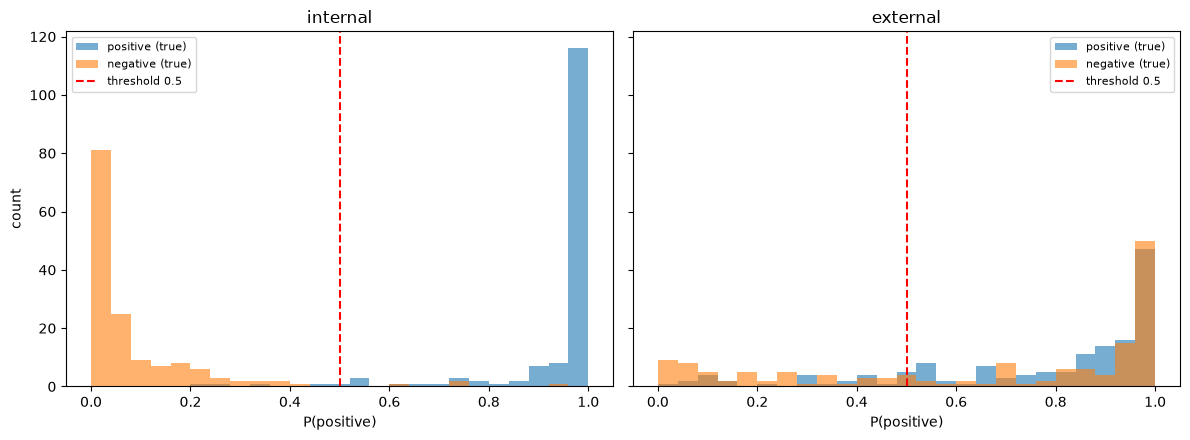

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, split in zip(axes, ['internal', 'external']):
    y, p = results[split]['labels'].astype(bool), results[split]['prob_pos']
    ax.hist(p[y],  bins=25, range=(0, 1), alpha=0.6, label=f'{class_names[1]} (true)')
    ax.hist(p[~y], bins=25, range=(0, 1), alpha=0.6, label=f'{class_names[0]} (true)')
    ax.axvline(0.5, color='red', ls='--', label='threshold 0.5')
    ax.set_title(split); ax.set_xlabel('P(%s)' % class_names[1]); ax.legend(fontsize=8)
axes[0].set_ylabel('count')
plt.tight_layout(); plt.savefig(f'case{CASE}_prob_dist.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. ROC curves

Threshold-independent view of ranking quality. AUC near 1.0 means the scores still separate the
classes (the problem is the operating threshold / calibration); AUC dropping toward 0.5 means the
scores themselves no longer carry the signal on the external set.

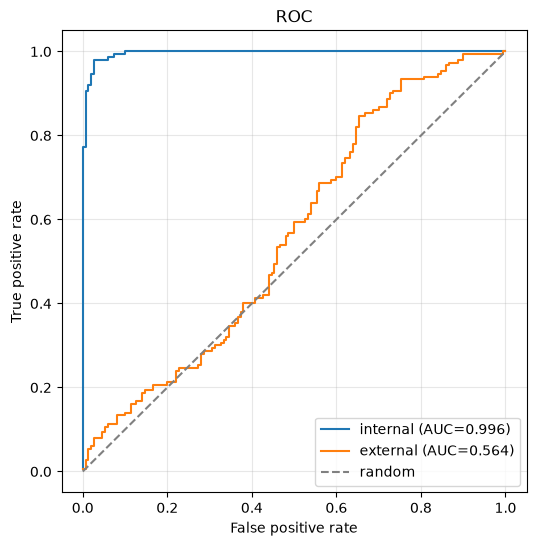

In [9]:
def roc(labels, probs):
    order = np.argsort(-probs); y = labels[order].astype(int)
    P, N = y.sum(), (1 - y).sum()
    tpr = np.cumsum(y) / P
    fpr = np.cumsum(1 - y) / N
    return fpr, tpr, np.trapezoid(tpr, fpr)

plt.figure(figsize=(6, 6))
for split in ['internal', 'external']:
    fpr, tpr, auc = roc(results[split]['labels'], results[split]['prob_pos'])
    plt.plot(fpr, tpr, label=f'{split} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'gray', ls='--', label='random')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('ROC')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f'case{CASE}_roc.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Calibration (reliability diagram)

For a trustworthy confidence score, among predictions made with confidence *c* the accuracy should
be about *c* (the diagonal). We bin by **confidence** = max(p, 1-p) and plot the accuracy in each
bin. Points below the diagonal mean the model is **over-confident**. We also report the accuracy of
the high-confidence predictions the deployment would auto-trust.

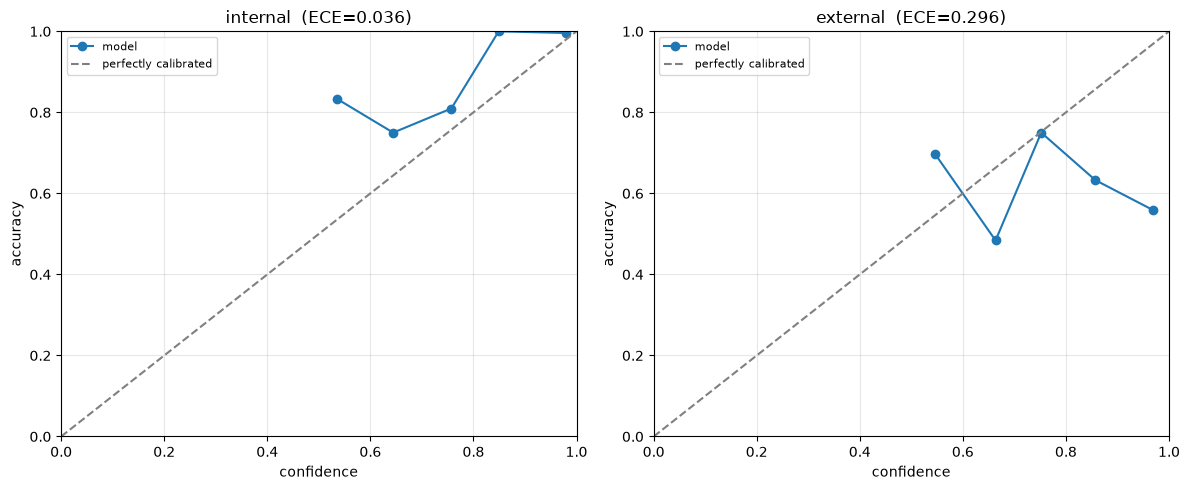

internal  conf>=0.90:   81.0% of samples, accuracy=0.996
internal  conf>=0.99:   42.3% of samples, accuracy=1.000
external  conf>=0.90:   54.3% of samples, accuracy=0.558
external  conf>=0.99:   20.0% of samples, accuracy=0.517


In [10]:
def reliability(labels, probs, n_bins=10):
    conf = np.maximum(probs, 1 - probs)            # confidence of the chosen class
    correct = ((probs > 0.5).astype(int) == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(conf, bins) - 1, 0, n_bins - 1)
    acc, mean_conf, count = [], [], []
    for b in range(n_bins):
        m = idx == b
        count.append(m.sum())
        acc.append(correct[m].mean() if m.any() else np.nan)
        mean_conf.append(conf[m].mean() if m.any() else np.nan)
    acc, mean_conf, count = map(np.array, (acc, mean_conf, count))
    ece = np.nansum(count / count.sum() * np.abs(acc - mean_conf))   # summary of the diagram
    return mean_conf, acc, count, ece

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, split in zip(axes, ['internal', 'external']):
    y, p = results[split]['labels'], results[split]['prob_pos']
    mc, acc, cnt, ece = reliability(y, p)
    ax.plot(mc, acc, marker='o', label='model')
    ax.plot([0, 1], [0, 1], 'gray', ls='--', label='perfectly calibrated')
    ax.set_title(f'{split}  (ECE={ece:.3f})'); ax.set_xlabel('confidence'); ax.set_ylabel('accuracy')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'case{CASE}_reliability.png', dpi=150, bbox_inches='tight'); plt.show()

# Accuracy of the predictions a high-confidence bypass would auto-trust
for split in ['internal', 'external']:
    y, p = results[split]['labels'], results[split]['prob_pos']
    conf = np.maximum(p, 1 - p); correct = ((p > 0.5).astype(int) == y)
    for thr in (0.9, 0.99):
        m = conf >= thr
        frac = m.mean(); a = correct[m].mean() if m.any() else float('nan')
        print(f"{split:9s} conf>={thr:.2f}:  {frac*100:5.1f}% of samples, accuracy={a:.3f}")

## 9. CAM saliency - where is the model looking?

Class Activation Mapping (Week 5 tutorial) highlights the image regions that drove the prediction.
We overlay CAMs for a few internal and external images. If the model attends to the region that
actually carries the target attribute we expect it to be robust; if it keys on background, borders
or an unrelated region, that points to a spurious/texture cue.

/tmp/ipykernel_1543/1942026051.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  conf = float(torch.softmax(out, 1).max())


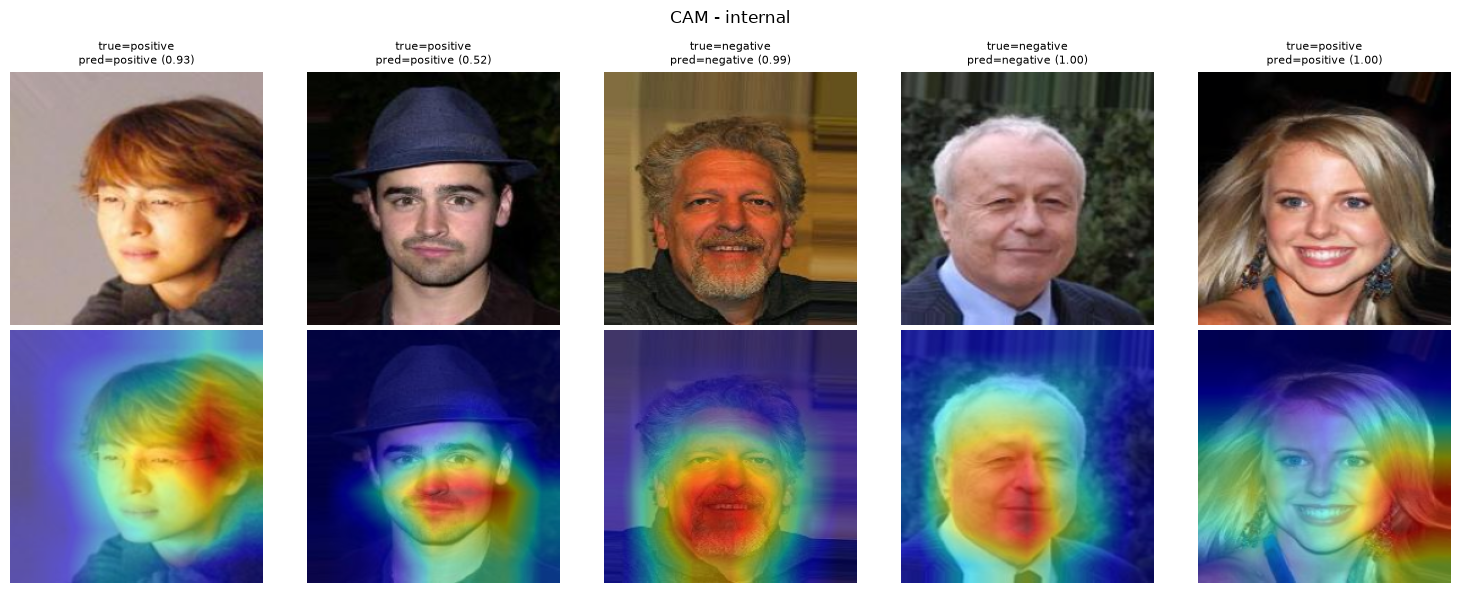

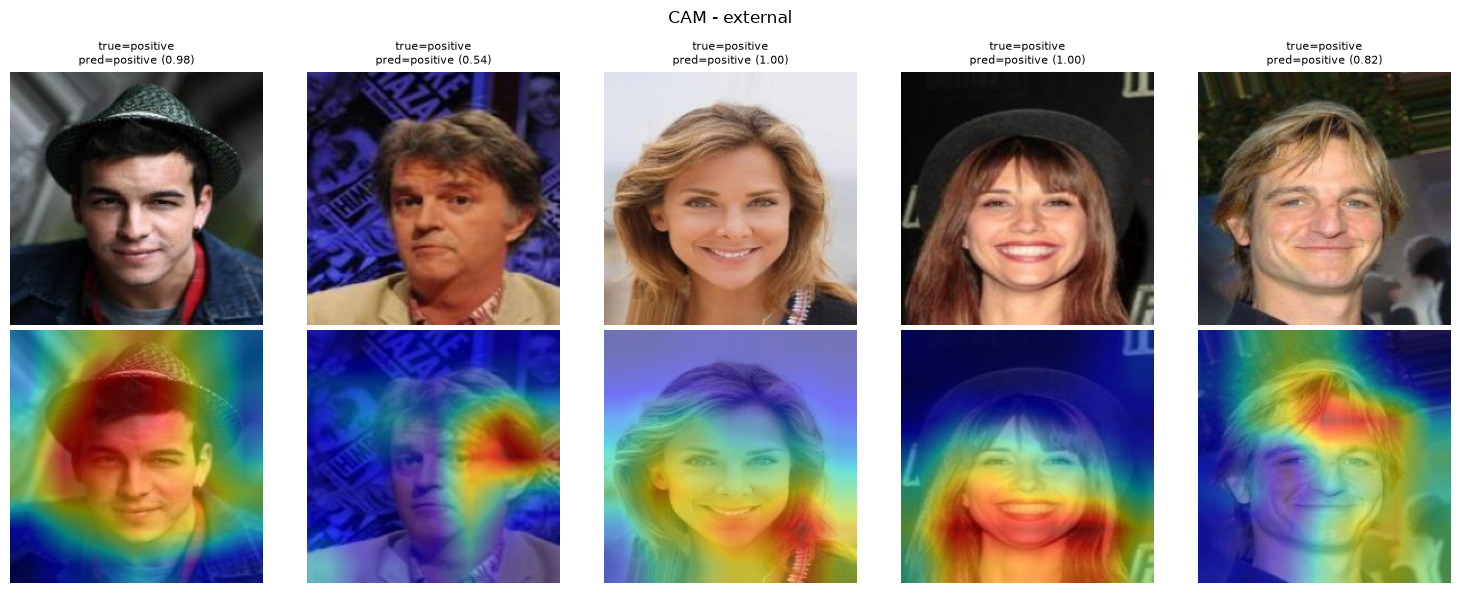

In [11]:
# hook the last conv block to grab its feature maps (as in the Week 5 tutorial)
activation = {}
def get_activation(name):
    def hook(m, i, o): activation[name] = o.detach()
    return hook
model.layer4[1].register_forward_hook(get_activation('feat'))
fc_weight = model.state_dict()['fc.weight']    # [2, 512]

def cam_for(ds, indices, title):
    fig, axes = plt.subplots(2, len(indices), figsize=(3*len(indices), 6))
    model.eval()
    for j, idx in enumerate(indices):
        x, y = ds[idx]
        out = model(x.unsqueeze(0).to(device))
        pred = int(out.argmax(1))
        conf = float(torch.softmax(out, 1).max())
        fmap = activation['feat'][0]                       # [512, h, w]
        cam = torch.sum(fc_weight[pred][:, None, None] * fmap, dim=0)
        cam = cam.clamp(min=0); cam = cam / (cam.max() + 1e-8)
        cam = torch.nn.functional.interpolate(cam[None, None], size=(224, 224),
                mode='bilinear', align_corners=False).squeeze().cpu().numpy()
        disp = x.numpy().transpose(1, 2, 0) * imagenet_stds + imagenet_means
        disp = np.clip(disp, 0, 1)
        axes[0, j].imshow(disp); axes[0, j].axis('off')
        axes[0, j].set_title(f'true={class_names[y]}\npred={class_names[pred]} ({conf:.2f})', fontsize=8)
        axes[1, j].imshow(disp); axes[1, j].imshow(cam, cmap='jet', alpha=0.5); axes[1, j].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

rng = np.random.default_rng(0)
cam_for(internal_ds, rng.choice(len(internal_ds), 5, replace=False), 'CAM - internal')
cam_for(external_ds, rng.choice(len(external_ds), 5, replace=False), 'CAM - external')

## 10. Observations

**Internal vs external.** Internally the model is accurate and reasonably calibrated (acc 0.973, AUC 0.996, ECE 0.036), so the lab-phase high-confidence bypass looked safe. Externally calibration collapses: ECE 0.036 → 0.296 and the reliability curve sits far below the diagonal. **Decisive test on the bypass threshold:** of predictions issued at ≥ 0.90 confidence, only **55.8%** are correct externally (≥ 0.99: 51.7%), versus ≈ 100% internally — the bypass auto-publishes near-coin-flip predictions labelled near-certain. External AUC is 0.564 (≈ chance): the scores carry little real signal, yet the softmax still emits extreme probabilities.

**Root cause — model over-confidence / miscalibration.** The predicted probabilities are untrustworthy on the field data, so a fixed 90% confidence gate no longer means what it did in the lab.

**Recommendation.** Stop trusting raw confidence for the bypass. Recalibrate probabilities (temperature / Platt scaling) on held-out external data and re-derive the auto-publish threshold from the *calibrated* confidence so that "≥ 90%" reflects true ≈ 90% accuracy; verify with a reliability diagram and ECE. Restore human review for this population and monitor ECE and high-confidence accuracy in production.